# 08. Model Diagnosis - LightGBM

This notebook performs a targeted diagnostic evaluation of the best-performing model (LightGBM) to validate reliability, generalization, and robustness.

## Scope
- Focuses only on LightGBM
- Reuses existing artifacts from previous notebooks
- Performs no hyperparameter tuning, no statistical tests, and no pipeline redesign

In [1]:
from pathlib import Path
import json
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, learning_curve, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.calibration import calibration_curve

import lightgbm as lgb

# Project root/bootstrap for utils import
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.plot_config import (
    apply_plot_style,
    clean_ax,
    CB_BLUE,
    CB_ORANGE,
    CB_GREEN,
    CB_RED,
    IEEE_SINGLE_COL,
    IEEE_DOUBLE_COL,
)

warnings.filterwarnings("ignore")
apply_plot_style()

RANDOM_SEED = 42
TABLES_DIR = ROOT / "results" / "tables"
FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f"Project root: {ROOT}")
print(f"Tables dir:   {TABLES_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01
Tables dir:   C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables
Figures dir:  C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures


## 1) Load Existing Artifacts

Reuse only existing outputs from previous notebooks.

In [2]:
# Required result tables
baseline_test_df = pd.read_csv(TABLES_DIR / "baseline_test_results_clean.csv")
tpe_test_df = pd.read_csv(TABLES_DIR / "TPE_test_results.csv")
gwo_test_df = pd.read_csv(TABLES_DIR / "GWO_test_results.csv")
tpe_best_params_df = pd.read_csv(TABLES_DIR / "TPE_best_params.csv")
gwo_best_params_df = pd.read_csv(TABLES_DIR / "GWO_best_params.csv")

# Optional legacy comparison table (if available)
comparison_path = TABLES_DIR / "comparison_baseline_vs_tpe_vs_gwo.csv"
comparison_df = pd.read_csv(comparison_path) if comparison_path.exists() else None
if comparison_df is None:
    print("Note: comparison_baseline_vs_tpe_vs_gwo.csv not found; selecting final variant from TPE/GWO test tables.")

# Core artifacts from previous notebooks
X_train = np.load(TABLES_DIR / "X_train.npy")
X_test = np.load(TABLES_DIR / "X_test.npy")
y_train = np.load(TABLES_DIR / "y_train.npy")
y_test = np.load(TABLES_DIR / "y_test.npy")

with open(TABLES_DIR / "selected_features.json", "r", encoding="utf-8") as f:
    selected_features = json.load(f)

with open(TABLES_DIR / "train_test_split_info.json", "r", encoding="utf-8") as f:
    split_info = json.load(f)

scaler_reference_df = pd.read_csv(TABLES_DIR / "baseline_optimal_scalers.csv")

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")
print(f"Selected features count: {len(selected_features)}")
print(f"Split info random_state: {split_info.get('random_state', 'N/A')}")

Note: comparison_baseline_vs_tpe_vs_gwo.csv not found; selecting final variant from TPE/GWO test tables.
X_train shape: (48000, 13), X_test shape: (12000, 13)
y_train shape: (48000,), y_test shape: (12000,)
Selected features count: 13
Split info random_state: 42


## 2) Identify Final LightGBM Variant and Reconstruct Pipeline

In [3]:
def sanitize_lgbm_params(raw_row: pd.Series) -> dict:
    """Convert parameter row from CSV into a valid LightGBM parameter dictionary."""
    int_keys = {
        "n_estimators",
        "num_leaves",
        "max_depth",
        "min_child_samples",
        "min_data_in_leaf",
        "subsample_freq",
    }
    drop_keys = {"Model", "Optimal_Scaler", "Best_CV_Mean", "Best_Trial", "Best_Iteration"}

    params = {}
    for key, value in raw_row.items():
        if key in drop_keys:
            continue
        if pd.isna(value):
            continue
        if key in int_keys:
            params[key] = int(round(float(value)))
        elif isinstance(value, (np.integer, int)):
            params[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            params[key] = float(value)
        else:
            params[key] = value
    return params


def build_scaler(name: str):
    scalers = {
        "Raw": None,
        "Standard": StandardScaler(),
        "MinMax": MinMaxScaler(),
        "Robust": RobustScaler(),
        "Power": PowerTransformer(method="yeo-johnson"),
        "Quantile": QuantileTransformer(output_distribution="uniform"),
    }
    if name not in scalers:
        raise ValueError(f"Unknown scaler: {name}")
    return scalers[name]


# Compare LightGBM test performance between TPE and GWO
lgbm_tpe = tpe_test_df.loc[tpe_test_df["Model"] == "LGBM"].iloc[0].copy()
lgbm_gwo = gwo_test_df.loc[gwo_test_df["Model"] == "LGBM"].iloc[0].copy()

candidates = pd.DataFrame([
    {"Optimizer": "TPE", **lgbm_tpe.to_dict()},
    {"Optimizer": "GWO", **lgbm_gwo.to_dict()},
])

# Deterministic selection: highest Accuracy, then highest AUC, then lowest LogLoss
candidates_sorted = candidates.sort_values(
    by=["Accuracy", "AUC", "LogLoss"],
    ascending=[False, False, True],
).reset_index(drop=True)

selected = candidates_sorted.iloc[0]
selected_optimizer = selected["Optimizer"]
selected_scaler = selected["Optimal_Scaler"]

if selected_optimizer == "TPE":
    lgbm_params_row = tpe_best_params_df.loc[tpe_best_params_df["Model"] == "LGBM"].iloc[0]
else:
    lgbm_params_row = gwo_best_params_df.loc[gwo_best_params_df["Model"] == "LGBM"].iloc[0]

lgbm_params = sanitize_lgbm_params(lgbm_params_row)

lgbm_model = lgb.LGBMClassifier(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
    **lgbm_params,
)

scaler_obj = build_scaler(selected_scaler)
if scaler_obj is None:
    final_pipeline = Pipeline([("model", lgbm_model)])
else:
    final_pipeline = Pipeline([
        ("scaler", clone(scaler_obj)),
        ("model", lgbm_model),
    ])

print("Final LightGBM variant selected")
print(candidates_sorted[["Optimizer", "Accuracy", "AUC", "LogLoss"]])
print(f"Selected optimizer: {selected_optimizer}")
print(f"Selected scaler: {selected_scaler}")
print(f"Num hyperparameters loaded: {len(lgbm_params)}")

Final LightGBM variant selected
  Optimizer  Accuracy       AUC   LogLoss
0       GWO  0.999083  0.999995  0.002970
1       TPE  0.999083  0.999995  0.005067
Selected optimizer: GWO
Selected scaler: Raw
Num hyperparameters loaded: 9


In [4]:
# Fit on full training split only
final_pipeline.fit(X_train, y_train)

# Predictions and probabilities
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)

train_proba = final_pipeline.predict_proba(X_train)
test_proba = final_pipeline.predict_proba(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

# Binary setup in this project: positive-class probability for ROC
train_pos_proba = train_proba[:, 1]
test_pos_proba = test_proba[:, 1]

# Predicted-class confidence
train_conf = np.max(train_proba, axis=1)
test_conf = np.max(test_proba, axis=1)

print(f"Train accuracy: {train_acc:.6f}")
print(f"Test accuracy:  {test_acc:.6f}")

Train accuracy: 1.000000
Test accuracy:  0.999083


## 3) Learning Curve (Overfitting Check)

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\learning_curve_plot.png
Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\learning_curve_plot.pdf


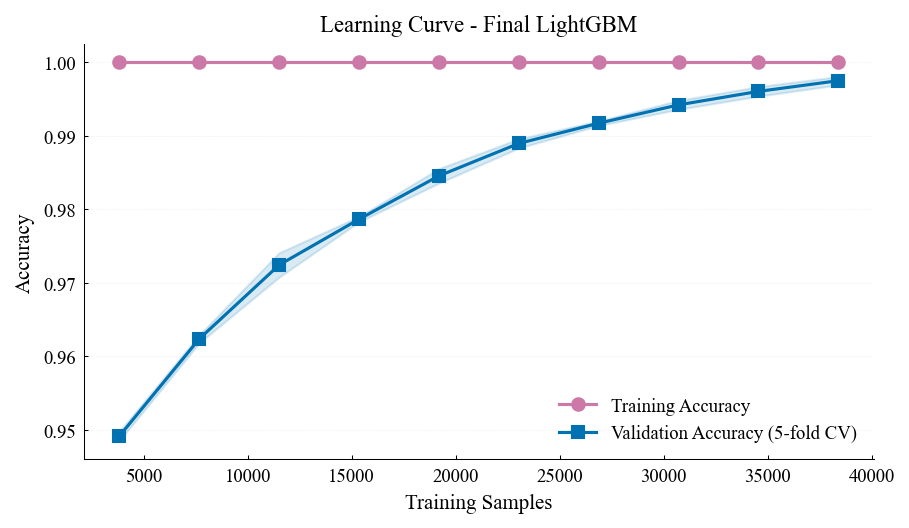

In [5]:
train_sizes = np.linspace(0.1, 1.0, 10)

lc_train_sizes, lc_train_scores, lc_val_scores = learning_curve(
    estimator=final_pipeline,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=CV,
    scoring="accuracy",
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_SEED,
)

lc_train_mean = lc_train_scores.mean(axis=1)
lc_train_std = lc_train_scores.std(axis=1)
lc_val_mean = lc_val_scores.mean(axis=1)
lc_val_std = lc_val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL * 0.95, 3.6))
ax.plot(lc_train_sizes, lc_train_mean, marker="o", color=CB_RED, label="Training Accuracy")
ax.fill_between(
    lc_train_sizes,
    lc_train_mean - lc_train_std,
    lc_train_mean + lc_train_std,
    color=CB_RED,
    alpha=0.15,
)
ax.plot(lc_train_sizes, lc_val_mean, marker="s", color=CB_BLUE, label="Validation Accuracy (5-fold CV)")
ax.fill_between(
    lc_train_sizes,
    lc_val_mean - lc_val_std,
    lc_val_mean + lc_val_std,
    color=CB_BLUE,
    alpha=0.15,
)

ax.set_xlabel("Training Samples")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve - Final LightGBM")
ax.legend(frameon=False, loc="lower right")
clean_ax(ax)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"learning_curve_plot.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()

## 4) Generalization Gap Table

In [6]:
cv_scores = cross_validate(
    estimator=final_pipeline,
    X=X_train,
    y=y_train,
    cv=CV,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=False,
)
cv_mean_acc = float(np.mean(cv_scores["test_score"]))

generalization_gap_df = pd.DataFrame([
    {
        "Train_Accuracy": train_acc,
        "CV_Mean_Accuracy": cv_mean_acc,
        "Test_Accuracy": test_acc,
        "Train_vs_Test_Gap": train_acc - test_acc,
        "CV_vs_Test_Gap": cv_mean_acc - test_acc,
    }
])

gap_out = TABLES_DIR / "model_generalization_gap.csv"
generalization_gap_df.to_csv(gap_out, index=False)
print(f"Saved: {gap_out}")
generalization_gap_df

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\model_generalization_gap.csv


,Train_Accuracy,CV_Mean_Accuracy,Test_Accuracy,Train_vs_Test_Gap,CV_vs_Test_Gap
0,1.0,0.997521,0.999083,0.000917,-0.001563


## 5) Confusion Matrix

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\confusion_matrix.png
Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\confusion_matrix.pdf


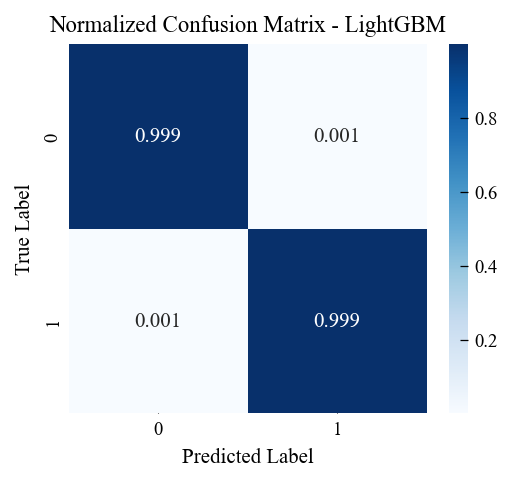

In [7]:
cm = confusion_matrix(y_test, test_pred, normalize="true")
labels = np.unique(y_test)

fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL * 1.1, 3.2))
sns.heatmap(
    cm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Normalized Confusion Matrix - LightGBM")
clean_ax(ax)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"confusion_matrix.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()

## 6) ROC Curve

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\roc_curve.png
Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\roc_curve.pdf


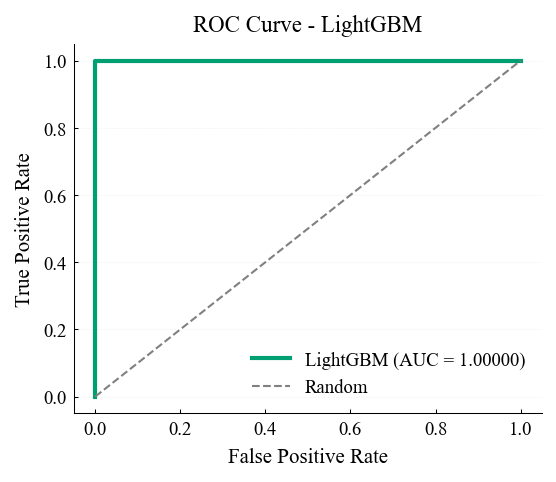

ROC-AUC: 0.999995


In [8]:
fpr, tpr, _ = roc_curve(y_test, test_pos_proba)
roc_auc = roc_auc_score(y_test, test_pos_proba)

fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL * 1.15, 3.2))
ax.plot(fpr, tpr, color=CB_GREEN, lw=2, label=f"LightGBM (AUC = {roc_auc:.5f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - LightGBM")
ax.legend(frameon=False, loc="lower right")
clean_ax(ax)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"roc_curve.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()
print(f"ROC-AUC: {roc_auc:.6f}")

## 7) Prediction Confidence Analysis

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\prediction_confidence_distribution.png
Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\prediction_confidence_distribution.pdf


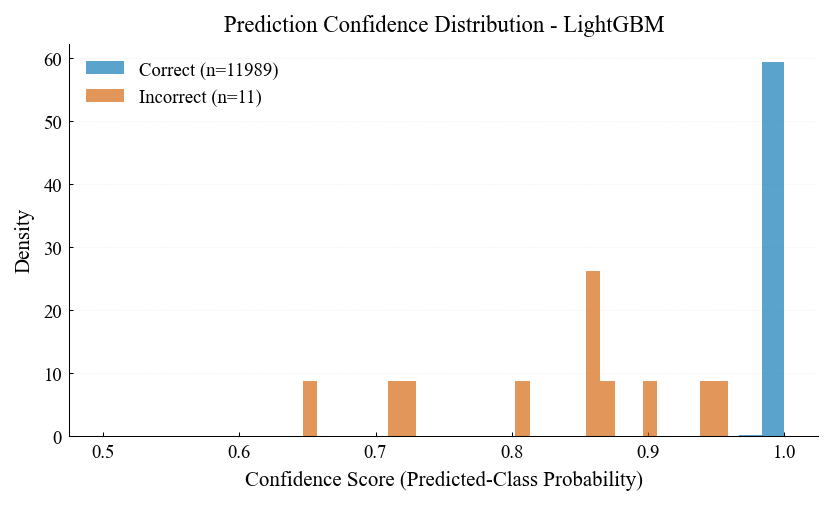

In [9]:
is_correct = (test_pred == y_test)
correct_conf = test_conf[is_correct]
incorrect_conf = test_conf[~is_correct]

fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL * 0.9, 3.4))
ax.hist(correct_conf, bins=30, alpha=0.65, color=CB_BLUE, label=f"Correct (n={correct_conf.size})", density=True)
ax.hist(incorrect_conf, bins=30, alpha=0.65, color=CB_ORANGE, label=f"Incorrect (n={incorrect_conf.size})", density=True)
ax.set_xlabel("Confidence Score (Predicted-Class Probability)")
ax.set_ylabel("Density")
ax.set_title("Prediction Confidence Distribution - LightGBM")
ax.legend(frameon=False)
clean_ax(ax)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"prediction_confidence_distribution.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()

## 8) Error Analysis Table

In [10]:
error_analysis_df = pd.DataFrame({
    "True_Label": y_test,
    "Predicted_Label": test_pred,
    "Predicted_Probability": test_pos_proba,
    "Confidence_Score": test_conf,
})
error_analysis_df["Correct"] = (error_analysis_df["True_Label"] == error_analysis_df["Predicted_Label"]).astype(int)

error_out = TABLES_DIR / "error_analysis.csv"
error_analysis_df.to_csv(error_out, index=False)
print(f"Saved: {error_out}")

error_analysis_df.head()

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\error_analysis.csv


,True_Label,Predicted_Label,Predicted_Probability,Confidence_Score,Correct
0,1,1,1.000000,1.000000,1
1,0,0,0.000010,0.999990,1
2,0,0,0.000394,0.999606,1
3,0,0,0.023058,0.976942,1
4,1,1,0.999987,0.999987,1


## 9) Optional Calibration Curve

Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\calibration_curve.png
Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\calibration_curve.pdf


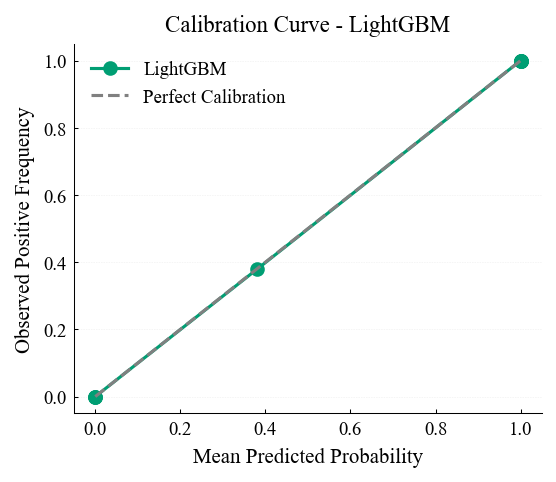

In [11]:
prob_true, prob_pred = calibration_curve(y_test, test_pos_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL * 1.15, 3.2))
ax.plot(prob_pred, prob_true, marker="o", color=CB_GREEN, label="LightGBM")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Positive Frequency")
ax.set_title("Calibration Curve - LightGBM")
ax.legend(frameon=False, loc="upper left")
clean_ax(ax)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"calibration_curve.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()

## 10) Reviewer-Focused Interpretation

- Overfitting check: learning curve and train/CV/test gap table indicate whether training performance is aligned with validation and test behavior.
- Generalization: consistent high performance across CV and held-out test supports stability under unseen data.
- High-accuracy credibility: confusion matrix, ROC/AUC, and confidence distribution provide behavioral evidence beyond a single scalar metric.
- Reliability: error-analysis table exposes individual prediction outcomes and model certainty, enabling transparent auditability.

This notebook validates model trustworthiness using the fixed final configuration and does not attempt to improve performance.